In [1]:
import pandas as pd
from pycaret.classification import *
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import RepeatedStratifiedKFold

In [2]:
dados = pd.read_csv("/workspaces/CEA-1/dados_filtrados.csv")
linhas, colunas = dados.shape
print("Dados:", linhas, "linhas e", colunas, "colunas")

# Substitui os espaços nas colunas categóricas ANTES de usar os dados
colunas_categoricas = ['cls_compl_ajustada', 'cls_ei_ajustada', 'cor']
for col in colunas_categoricas:
    if col in dados.columns:
        dados[col] = dados[col].astype(str).str.replace(' ', '_')


Dados: 1030 linhas e 65 colunas


In [6]:
print("Nomes das colunas do dataset 'dados':")
print(dados.columns.tolist())

Nomes das colunas do dataset 'dados':
['cls_fin_ajustada', 'dt_not_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'cls_eien', 'idade_anos', 'evol_num', 'cls_compl_ajustada', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas', 'cls_fin_reg_logistica']


# **EANG vs EI**

In [3]:
colunas_para_remover = [
    'cls_fin_ajustada', 
    'gestante', 
    'cod_prod_ajustada', 
    'cls_ei_ajustada', 
    'cls_eien', 
    'evol_num', 
    'cls_compl_ajustada', 
    'dor_no_corpo', 
    'artralgia', 
    'cefaleia', 
    'dor', 
    'exantema_local', 
    'exantema', 
    'edema', 
    'eritema', 
    'calor', 
    'enduracao', 
    'abscesso_quente', 
    'lesao', 
    'linfonodomegalia', 
    'prurido', 
    'febre', 
    'nausea', 
    'emese', 
    'diarreia', 
    'tontura', 
    'sincope', 
    'parestesia', 
    'convulsao', 
    'confusao_mental', 
    'fraqueza', 
    'hipotensao', 
    'taquicardia', 
    'bradicardia', 
    'extremidades_frias', 
    'palidez', 
    'sudorese', 
    'urticaria', 
    'broncoespasmo', 
    'dispneia', 
    'angioedema', 
    'tremor', 
    'fotofobia', 
    'visao_turva', 
    'guillain_barre', 
    'encefalite', 
    'epilepsia', 
    'paralisia', 
    'purpura_trombocitopenica'
]

# Remove todas as colunas de uma vez só
dados_eang_vs_ei = dados.drop(columns=colunas_para_remover)

In [4]:
dados_eang_vs_ei.value_counts()

dt_not_ano  regiao    pais_nasc      sexo       cor            dt_apl_ano  dose_ajustada  via_adm_ajustada  local_aplic_ajustada   tp_med    tp_atd_ajustada  idade_anos  dor_abdominal  manifestacoes_locais  manifestacoes_sistemicas  cls_fin_reg_logistica
2020        Sudeste   BRASIL         feminino   Nao_Informado  2019        apenas 67      vazio             não informado          Ignorado  Observacao       9           0              0                     0                         False                    6
                                     masculino  Nao_Informado  2020        apenas 67      intramuscular     Deltóide Esquerdo      Ignorado  Observacao       10          0              0                     0                         False                    5
2021        Sul       BRASIL         masculino  Nao_Informado  2020        apenas 67      intramuscular     Ventroglúteo Direito   Ignorado  Observacao       11          0              0                     0                 

In [5]:
ambiente = setup(data=dados_eang_vs_ei, target='cls_fin_reg_logistica', session_id=42)

,Description,Value
0,Session id,42
1,Target,cls_fin_reg_logistica
2,Target type,Binary
3,Original data shape,"(1030, 16)"
4,Transformed data shape,"(1030, 32)"
5,Transformed train set shape,"(721, 32)"
6,Transformed test set shape,"(309, 32)"
7,Numeric features,6
8,Categorical features,9
9,Preprocess,True


In [6]:
melhor_modelo = compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9639,0.9857,0.9554,0.9766,0.9652,0.9277,0.9293,0.1290
lr,Logistic Regression,0.9514,0.9816,0.9296,0.9788,0.9531,0.9028,0.9050,0.3340
gbc,Gradient Boosting Classifier,0.9528,0.9815,0.9399,0.9712,0.9547,0.9055,0.9073,0.1000
lda,Linear Discriminant Analysis,0.9445,0.9812,0.9086,0.9861,0.9452,0.8892,0.8932,0.0670
ridge,Ridge Classifier,0.9445,0.9810,0.9086,0.9861,0.9453,0.8892,0.8931,0.0660
lightgbm,Light Gradient Boosting Machine,0.9570,0.9798,0.9502,0.9689,0.9585,0.9138,0.9158,13.2610
ada,Ada Boost Classifier,0.9376,0.9757,0.9242,0.9579,0.9401,0.8749,0.8768,0.0910
et,Extra Trees Classifier,0.9542,0.9737,0.9502,0.9644,0.9561,0.9082,0.9105,0.1120
nb,Naive Bayes,0.9487,0.9683,0.9424,0.9616,0.9511,0.8971,0.8989,0.0550
qda,Quadratic Discriminant Analysis,0.9112,0.9675,0.8518,0.9803,0.9098,0.8236,0.8338,0.0780


In [7]:
# 1. Garante que TODAS as colunas de texto do DataFrame correto fiquem sem espaços
colunas_texto = dados_eang_vs_ei.select_dtypes(include=['object', 'category']).columns

for col in colunas_texto:
    # Substitui espaços por _ dentro dos valores
    dados_eang_vs_ei[col] = dados_eang_vs_ei[col].astype(str).str.replace(' ', '_')
    
    # Prevenção extra: substitui também os hifens, que o LightGBM também odeia
    dados_eang_vs_ei[col] = dados_eang_vs_ei[col].str.replace('-', '_')

# 2. Agora sim, passamos os dados limpos para o setup
ambiente = setup(
    data=dados_eang_vs_ei, 
    target='cls_fin_reg_logistica',
    # ... (mantenha todo o resto do seu setup exatamente igual)
)
ambiente = setup(
    data=dados_eang_vs_ei, target='cls_fin_reg_logistica',
        
    # --- BALANCEAMENTO DE CLASSES ---
    fix_imbalance = True,
    fix_imbalance_method = ADASYN(random_state=42), # Mais focado nas fronteiras difíceis
    
    # --- TRATAMENTO DE DISTRIBUIÇÕES ASSIMÉTRICAS ---
    transformation = True,          # Transforma dados para mais perto do formato de sino (Normal)
    normalize = True,               # Escala os dados
    normalize_method = 'robust',    # Ignora outliers na hora de escalar
    
    # --- PROTEÇÃO PARA POUCOS DADOS ---
    feature_selection = True,       # Remove colunas inúteis
    n_features_to_select = 0.8,     # Mantém apenas as 80% melhores colunas
    fold_strategy = cv_repetida,    # Usa a nossa validação cruzada hiper-rigorosa
    
    session_id = 42
)

# 3. Manda rodar a competição!
melhor_modelo = compare_models(sort='AUC')


,Description,Value
0,Session id,4176
1,Target,cls_fin_reg_logistica
2,Target type,Binary
3,Original data shape,"(1030, 16)"
4,Transformed data shape,"(1030, 32)"
5,Transformed train set shape,"(721, 32)"
6,Transformed test set shape,"(309, 32)"
7,Numeric features,6
8,Categorical features,9
9,Preprocess,True


NameError: name 'cv_repetida' is not defined

# **EAG vs EANG**

In [36]:
# Lista de valores que retornam True e False
targets_true = ['EAG']
targets_false = ['EANG']

dados_eang_vs_eag = dados[dados['cls_fin_ajustada'] != 'Inclassificável']
dados_eang_vs_eag = dados_eang_vs_eag[dados_eang_vs_eag['cls_fin_ajustada'] != 'EI']
dados_eang_vs_eag = dados_eang_vs_eag[dados_eang_vs_eag['cls_fin_ajustada'] != 'EI - evento adverso']

# Cria a nova variável comparando com a lista
dados_eang_vs_eag['cls_fin_reg_logistica_eag_eang'] = dados_eang_vs_eag['cls_fin_ajustada'].isin(targets_true)
dados_eang_vs_ei = dados_eang_vs_eag.drop('cls_fin_ajustada', axis=1)
# Validação: verificar que temos apenas os valores esperados
print("Valores únicos em 'cls_fin_ajustada' (após filtro):")
print(dados_eang_vs_eag['cls_fin_ajustada'].unique())
print("\nDistribuição da variável de regressão logística:")

Valores únicos em 'cls_fin_ajustada' (após filtro):
['EANG' 'EAG']

Distribuição da variável de regressão logística:


In [41]:
from pycaret.classification import *
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.model_selection import RepeatedStratifiedKFold
import pandas as pd

cv_repetida = RepeatedStratifiedKFold(n_splits=3, n_repeats=3, random_state=42)

# ── limpeza de strings ────────────────────────────────────
colunas_texto = dados_eang_vs_eag.select_dtypes(include=['object', 'category']).columns
for col in colunas_texto:
    dados_eang_vs_eag[col] = (dados_eang_vs_eag[col]
                               .astype(str)
                               .str.replace(' ', '_')
                               .str.replace('-', '_'))

# ── configurações base compartilhadas ────────────────────
cfg_base = dict(
    data               = dados_eang_vs_eag,
    target             = 'cls_fin_reg_logistica_eag_eang',
    transformation     = True,
    normalize          = True,
    normalize_method   = 'robust',
    feature_selection  = True,
    n_features_to_select = 0.8,
    fold_strategy      = cv_repetida,
    fix_imbalance      = True,
    session_id         = 42,
    verbose            = False,
)

# ── rodar os 3 métodos e salvar resultados ───────────────
resultados = {}

metodos = {
    'SMOTE'    : SMOTE(random_state=42),
    'ADASYN'   : ADASYN(random_state=42),
    'SMOTEENN' : SMOTEENN(random_state=42),
}

for nome, metodo in metodos.items():
    print(f"\n{'='*50}")
    print(f"Rodando com: {nome}")
    print('='*50)

    setup(**cfg_base, fix_imbalance_method=metodo)

    modelo = compare_models(include=['lr'], sort='AUC', verbose=True)
    metricas = pull()   # pega a tabela de resultados do último compare_models

    resultados[nome] = {
        'modelo'  : modelo,
        'metricas': metricas,
    }

# ── tabela comparativa final ──────────────────────────────
print("\n\n" + "="*60)
print("COMPARATIVO FINAL — Regressão Logística por método de balanceamento")
print("="*60)

linhas = []
for nome, res in resultados.items():
    row = res['metricas'][['Model', 'AUC', 'Recall', 'Prec.', 'F1', 'Kappa']].iloc[0].copy()
    row['Método'] = nome
    linhas.append(row)

df_comparativo = pd.DataFrame(linhas).set_index('Método')
print(df_comparativo.to_string())


Rodando com: SMOTE
[LightGBM] [Info] Number of positive: 355, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1824
[LightGBM] [Info] Number of data points in the train set: 710, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9488,0.6587,0.3222,0.3333,0.3275,0.3270,0.3272,0.2178



Rodando com: ADASYN
[LightGBM] [Info] Number of positive: 362, number of negative: 355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000525 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1842
[LightGBM] [Info] Number of data points in the train set: 717, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.504881 -> initscore=0.019526
[LightGBM] [Info] Start training from score 0.019526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9497,0.6667,0.3333,0.3333,0.3333,0.3333,0.3333,0.2244



Rodando com: SMOTEENN
[LightGBM] [Info] Number of positive: 355, number of negative: 265
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1850
[LightGBM] [Info] Number of data points in the train set: 620, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.572581 -> initscore=0.292388
[LightGBM] [Info] Start training from score 0.292388
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9488,0.6587,0.3222,0.3333,0.3275,0.3270,0.3272,0.2300




COMPARATIVO FINAL — Regressão Logística por método de balanceamento
                        Model     AUC  Recall   Prec.      F1   Kappa
Método                                                               
SMOTE     Logistic Regression  0.6587  0.3222  0.3333  0.3275  0.3270
ADASYN    Logistic Regression  0.6667  0.3333  0.3333  0.3333  0.3333
SMOTEENN  Logistic Regression  0.6587  0.3222  0.3333  0.3275  0.3270


In [38]:
# após criar o modelo final escolhido
modelo_final = finalize_model(resultados['SMOTE']['modelo'])
metricas_detalhadas = get_metrics()
print(metricas_detalhadas)

                Name Display Name  \
ID                                  
acc         Accuracy     Accuracy   
auc              AUC          AUC   
recall        Recall       Recall   
precision  Precision        Prec.   
f1                F1           F1   
kappa          Kappa        Kappa   
mcc              MCC          MCC   

                                              Score Function  \
ID                                                             
acc              <function accuracy_score at 0x7aefdbfe1120>   
auc        <pycaret.internal.metrics.BinaryMulticlassScor...   
recall     <pycaret.internal.metrics.BinaryMulticlassScor...   
precision  <pycaret.internal.metrics.BinaryMulticlassScor...   
f1         <pycaret.internal.metrics.BinaryMulticlassScor...   
kappa         <function cohen_kappa_score at 0x7aefdbfe1480>   
mcc           <function matthews_corrcoef at 0x7aefdbfe16c0>   

                                                      Scorer      Target  \
ID           

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

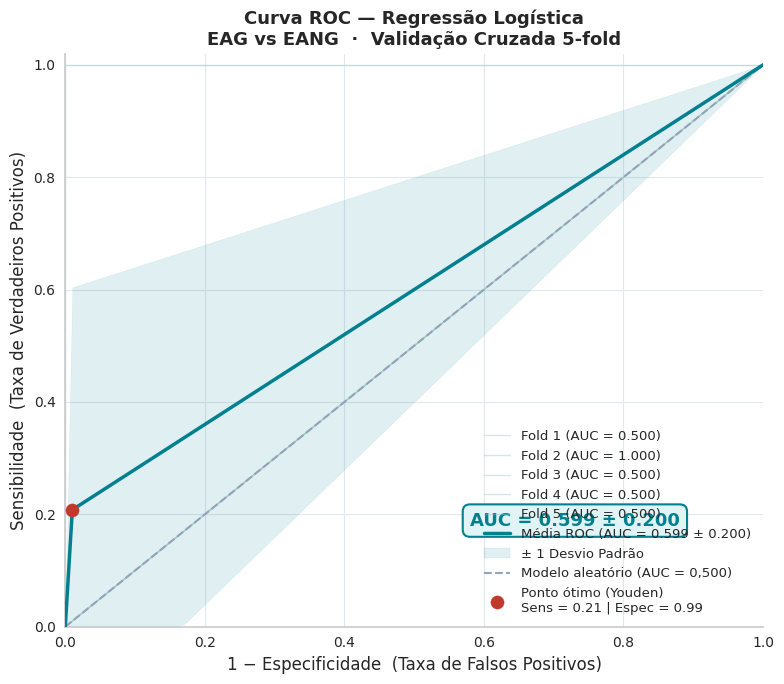


AUC por fold:
  Fold 1: 0.5000
  Fold 2: 1.0000
  Fold 3: 0.5000
  Fold 4: 0.5000
  Fold 5: 0.5000

Média: 0.5990
DP:    0.2000
IC 95% aprox.: [0.2070, 0.9910]


In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# ── extrair o pipeline treinado pelo PyCaret ─────────────
pipeline = get_config('pipeline')        # transformações
X        = get_config('X_transformed')  # dados já transformados
y        = get_config('y_transformed')  # desfecho

# ── cross-validation para curva ROC robusta ──────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs    = []
aucs    = []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(8, 7))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    modelo.fit(X_train, y_train)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_auc     = auc(fpr, tpr)
    aucs.append(fold_auc)

    # interpolar para média depois
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)

    ax.plot(fpr, tpr, color='#93C5C0', lw=1, alpha=0.4,
            label=f'Fold {fold+1} (AUC = {fold_auc:.3f})' if fold == 0 else f'Fold {fold+1} (AUC = {fold_auc:.3f})')

# ── curva média ───────────────────────────────────────────
mean_tpr        = np.mean(tprs, axis=0)
mean_tpr[-1]    = 1.0
mean_auc        = auc(mean_fpr, mean_tpr)
std_auc         = np.std(aucs)
std_tpr         = np.std(tprs, axis=0)

ax.plot(mean_fpr, mean_tpr,
        color='#028090', lw=2.5,
        label=f'Média ROC (AUC = {mean_auc:.3f} ± {std_auc:.3f})',
        zorder=5)

# ── banda de confiança ±1 DP ─────────────────────────────
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tpr_lower, tpr_upper,
                color='#028090', alpha=0.12,
                label='± 1 Desvio Padrão')

# ── linha de referência aleatória ────────────────────────
ax.plot([0, 1], [0, 1],
        linestyle='--', color='#94A3B8', lw=1.5,
        label='Modelo aleatório (AUC = 0,500)')

# ── ponto ótimo de Youden na curva média ─────────────────
idx_youden  = (mean_tpr - mean_fpr).argmax()
ax.scatter(mean_fpr[idx_youden], mean_tpr[idx_youden],
           color='#C0392B', zorder=6, s=90,
           label=f'Ponto ótimo (Youden)\n'
                 f'Sens = {mean_tpr[idx_youden]:.2f} | '
                 f'Espec = {1 - mean_fpr[idx_youden]:.2f}')

# ── anotação do AUC no gráfico ───────────────────────────
ax.text(0.58, 0.18,
        f'AUC = {mean_auc:.3f} ± {std_auc:.3f}',
        fontsize=13, color='#028090', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E0F4F5',
                  edgecolor='#028090', linewidth=1.5))

# ── formatação ───────────────────────────────────────────
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('1 − Especificidade  (Taxa de Falsos Positivos)', fontsize=12)
ax.set_ylabel('Sensibilidade  (Taxa de Verdadeiros Positivos)', fontsize=12)
ax.set_title('Curva ROC — Regressão Logística\n'
             'EAG vs EANG  ·  Validação Cruzada 5-fold',
             fontsize=13, fontweight='bold')

ax.legend(loc='lower right', fontsize=9.5, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='both', color='#E2E8F0', linewidth=0.8)

plt.tight_layout()
plt.savefig('roc_regressao_logistica.png', dpi=200, bbox_inches='tight')
plt.show()

# ── tabela de métricas por fold ───────────────────────────
print("\nAUC por fold:")
for i, a in enumerate(aucs):
    print(f"  Fold {i+1}: {a:.4f}")
print(f"\nMédia: {mean_auc:.4f}")
print(f"DP:    {std_auc:.4f}")
print(f"IC 95% aprox.: [{mean_auc - 1.96*std_auc:.4f}, {mean_auc + 1.96*std_auc:.4f}]")

Amostra final: 549 observações
EAG (1): 41 | EANG (0): 508
Proporção EAG: 7.5%

── Seleção stepwise ──────────────────────────────
  + Adicionada: convulsao (p=0.0000)
  + Adicionada: tp_atd_ajustada_Hospitalar (p=0.0000)
  + Adicionada: paralisia (p=0.0000)
  + Adicionada: dispneia (p=0.0001)
  + Adicionada: regiao_Sudeste (p=0.0064)
  + Adicionada: tp_med_Sim (p=0.0111)

Variáveis no modelo final: ['convulsao', 'tp_atd_ajustada_Hospitalar', 'paralisia', 'dispneia', 'regiao_Sudeste', 'tp_med_Sim']
Optimization terminated successfully.
         Current function value: 0.102670
         Iterations 9
                                 Logit Regression Results                                 
Dep. Variable:     cls_fin_reg_logistica_eag_eang   No. Observations:                  549
Model:                                      Logit   Df Residuals:                      542
Method:                                       MLE   Df Model:                            6
Date:                         

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

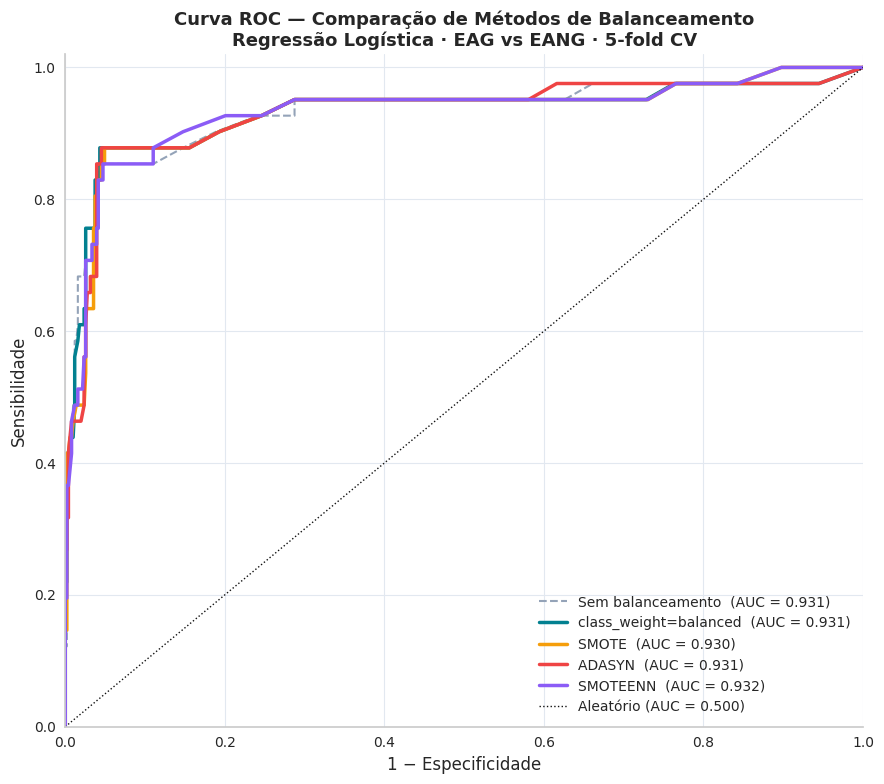


── AUC por método de balanceamento ────────────────
                          AUC
SMOTEENN               0.9315
ADASYN                 0.9314
Sem balanceamento      0.9311
class_weight=balanced  0.9307
SMOTE                  0.9302


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# ══════════════════════════════════════════════════════════
# ETAPA 1 — definir candidatas (p < 0.20 na bivariada)
# ══════════════════════════════════════════════════════════

# variáveis com p < 0.20 nos seus resultados bivariados
candidatas = [
    'regiao', 'idade_anos', 'sexo', 'dt_not_ano', 'dt_apl_ano',
    'local_aplic_ajustada', 'cor', 'pais_nasc', 'dose_ajustada',
    'gestante', 'tp_med', 'tp_atd_ajustada',
    'manifestacoes_sistemicas', 'manifestacoes_locais',
    # sintomas com p < 0.20
    'dor', 'eritema', 'edema', 'febre', 'cefaleia', 'emese',
    'sincope', 'palidez', 'convulsao', 'tontura', 'urticaria',
    'fraqueza', 'parestesia', 'hipotensao', 'dispneia', 'paralisia',
    'exantema', 'prurido', 'calor', 'nausea', 'dor_abdominal',
    'sudorese', 'lesao', 'diarreia', 'extremidades_frias',
    'artralgia', 'tremor', 'visao_turva', 'enduracao', 'taquicardia',
    'abscesso_quente', 'dor_no_corpo',
]

# ══════════════════════════════════════════════════════════
# ETAPA 2 — preparar dados
# ══════════════════════════════════════════════════════════

df = dados_eang_vs_eag.copy()
y  = df['cls_fin_reg_logistica_eag_eang'].astype(int)

# codificar categóricas
X_raw = pd.get_dummies(df[candidatas], drop_first=True).astype(float)

# remover colunas sem variância
X_raw = X_raw.loc[:, X_raw.std() > 0]

# alinhar índices e remover NaN
mask  = X_raw.notna().all(axis=1) & y.notna()
X_raw = X_raw[mask].reset_index(drop=True)
y     = y[mask].reset_index(drop=True)

print(f"Amostra final: {len(y)} observações")
print(f"EAG (1): {y.sum()} | EANG (0): {(y==0).sum()}")
print(f"Proporção EAG: {y.mean():.1%}")

# ══════════════════════════════════════════════════════════
# ETAPA 3 — seleção stepwise (forward + backward por AIC)
# ══════════════════════════════════════════════════════════

def stepwise_logit(X, y, threshold_in=0.05, threshold_out=0.10):
    """
    Seleção stepwise por p-valor.
    threshold_in  → p-valor para entrar no modelo
    threshold_out → p-valor para sair do modelo
    """
    incluidas = []
    
    while True:
        # FORWARD: testa cada variável fora do modelo
        excluidas = [c for c in X.columns if c not in incluidas]
        melhor_pval = threshold_in
        melhor_var  = None
        
        for var in excluidas:
            cols = incluidas + [var]
            X_temp = sm.add_constant(X[cols])
            try:
                modelo = sm.Logit(y, X_temp).fit(disp=False, maxiter=200)
                pval   = modelo.pvalues[var]
                if pval < melhor_pval:
                    melhor_pval = pval
                    melhor_var  = var
            except:
                continue
        
        if melhor_var:
            incluidas.append(melhor_var)
            print(f"  + Adicionada: {melhor_var} (p={melhor_pval:.4f})")
        
        # BACKWARD: remove variáveis que pioraram
        modelo_atual = sm.Logit(y, sm.add_constant(X[incluidas])).fit(disp=False, maxiter=200)
        pvals_atuais = modelo_atual.pvalues[incluidas]
        pior_var     = pvals_atuais.idxmax()
        pior_pval    = pvals_atuais.max()
        
        if pior_pval > threshold_out:
            incluidas.remove(pior_var)
            print(f"  - Removida:   {pior_var} (p={pior_pval:.4f})")
        
        # critério de parada
        if melhor_var is None:
            break
    
    return incluidas

print("\n── Seleção stepwise ──────────────────────────────")
variaveis_selecionadas = stepwise_logit(X_raw, y)
print(f"\nVariáveis no modelo final: {variaveis_selecionadas}")

# ══════════════════════════════════════════════════════════
# ETAPA 4 — modelo final com statsmodels (OR + IC 95%)
# ══════════════════════════════════════════════════════════

X_final = sm.add_constant(X_raw[variaveis_selecionadas])

modelo_final = sm.Logit(y, X_final).fit(maxiter=300)
print(modelo_final.summary())

# tabela de OR
params    = modelo_final.params
conf_int  = modelo_final.conf_int()
pvals     = modelo_final.pvalues

tabela_or = pd.DataFrame({
    'OR':        np.exp(params),
    'IC 2.5%':   np.exp(conf_int[0]),
    'IC 97.5%':  np.exp(conf_int[1]),
    'p-valor':   pvals
}).drop('const').sort_values('OR', ascending=False)

print("\n── Odds Ratios ajustados ──────────────────────────")
print(tabela_or.round(4).to_string())

# ══════════════════════════════════════════════════════════
# ETAPA 5 — testes de balanceamento + curvas ROC
# ══════════════════════════════════════════════════════════

X_sk = X_raw[variaveis_selecionadas].values

metodos = {
    'Sem balanceamento':          None,
    'class_weight=balanced':      'balanced',
    'SMOTE':                      SMOTE(random_state=42),
    'ADASYN':                     ADASYN(random_state=42),
    'SMOTEENN':                   SMOTEENN(random_state=42),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cores   = ['#94A3B8', '#028090', '#F59E0B', '#EF4444', '#8B5CF6']
fig, ax = plt.subplots(figsize=(9, 8))

resultados_bal = {}

for (nome, metodo), cor in zip(metodos.items(), cores):
    
    if metodo is None:
        # sem balanceamento
        clf = LogisticRegression(max_iter=500, random_state=42)
    elif metodo == 'balanced':
        clf = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
    else:
        # pipeline com oversampling
        clf = ImbPipeline([
            ('sampler', metodo),
            ('clf',     LogisticRegression(max_iter=500, random_state=42))
        ])
    
    # probabilidades via cross-validation
    y_prob = cross_val_predict(clf, X_sk, y, cv=cv, method='predict_proba')[:, 1]
    
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc     = auc(fpr, tpr)
    
    resultados_bal[nome] = {'auc': roc_auc, 'fpr': fpr, 'tpr': tpr}
    
    lw = 2.5 if nome != 'Sem balanceamento' else 1.5
    ls = '--' if nome == 'Sem balanceamento' else '-'
    ax.plot(fpr, tpr, color=cor, lw=lw, linestyle=ls,
            label=f'{nome}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Aleatório (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('1 − Especificidade', fontsize=12)
ax.set_ylabel('Sensibilidade', fontsize=12)
ax.set_title('Curva ROC — Comparação de Métodos de Balanceamento\n'
             'Regressão Logística · EAG vs EANG · 5-fold CV',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.92)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(color='#E2E8F0', linewidth=0.8)

plt.tight_layout()
plt.savefig('roc_balanceamento.png', dpi=200, bbox_inches='tight')
plt.show()

# ── tabela comparativa ────────────────────────────────────
print("\n── AUC por método de balanceamento ────────────────")
df_res = pd.DataFrame({k: {'AUC': v['auc']} for k, v in resultados_bal.items()}).T
print(df_res.sort_values('AUC', ascending=False).round(4).to_string())